# Emotions Analysis in Python



In [3]:
%pip install wordcloud matplotlib

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [96]:
#importing the main packages
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem.snowball import SnowballStemmer

#Download the required models for sentence tokenization
nltk.download('punkt_tab')

#Downloading stop words to remove
nltk.download('stopwords')

#import for creating a word cloud
from wordcloud import WordCloud

#import for the TF-IDF calculation
from sklearn.feature_extraction.text import TfidfVectorizer

#import for Leminization
from nltk.stem import WordNetLemmatizer

#download for Leminization
nltk.download('wordnet')

#import for test/train the data 
from sklearn.model_selection import train_test_split

#import for logistic 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay,
                            confusion_matrix,
                            roc_curve, 
                            auc)

[nltk_data] Downloading package punkt_tab to /home/user/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /home/user/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/user/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [5]:
SKIP_STEMMING = True

# Cleaning the Data

Here we import the data.


In [6]:
#read the dataframe in, lowercase the titles
em_df_original = pd.read_csv("Emotion.csv",index_col=0).rename(columns={"Emotion":"emotion"})
em_df_original

,text,emotion
0,i seriously hate one subject to death but now ...,hate
1,im so full of life i feel appalled,neutral
2,i sit here to write i start to dig out my feel...,neutral
3,ive been really angry with r and i feel like a...,anger
4,i feel suspicious if there is no one outside l...,neutral
...,...,...
839550,i feel like telling these horny devils to find...,neutral
839551,i began to realize that when i was feeling agi...,neutral
839552,i feel very curious be why previous early dawn...,neutral
839553,i feel that becuase of the tyranical nature of...,neutral


We make everything lowercase.

In [7]:
#Making the text column lower case
em_df_original['text'] = em_df_original['text'].str.lower()
em_df_original

,text,emotion
0,i seriously hate one subject to death but now ...,hate
1,im so full of life i feel appalled,neutral
2,i sit here to write i start to dig out my feel...,neutral
3,ive been really angry with r and i feel like a...,anger
4,i feel suspicious if there is no one outside l...,neutral
...,...,...
839550,i feel like telling these horny devils to find...,neutral
839551,i began to realize that when i was feeling agi...,neutral
839552,i feel very curious be why previous early dawn...,neutral
839553,i feel that becuase of the tyranical nature of...,neutral


# Remove Duplicates

First we sort by the text column to make sure any duplicates are back\-to\-back.


In [8]:
em_df_sorted = em_df_original.sort_values("text").reset_index(drop = True)
em_df_sorted

,text,emotion
0,a a documentary in which baby fur seals were b...,neutral
1,a a documentary in which baby fur seals were b...,neutral
2,a and i were walking along the new asia stairw...,fun
3,a and i were walking along the new asia stairw...,fun
4,a bad smelling cucumber,neutral
...,...,...
839550,you may find out that i am stupid and not to l...,neutral
839551,you told me psychology can help people to be h...,neutral
839552,you told me psychology can help people to be h...,neutral
839553,your prejudice against psychology students and...,neutral


In [9]:
# we generate a data frame of the first duplicates found 
em_df = em_df_sorted.drop_duplicates(subset="text",inplace=False,keep='first').reset_index(drop=True)
em_df

,text,emotion
0,a a documentary in which baby fur seals were b...,neutral
1,a and i were walking along the new asia stairw...,fun
2,a bad smelling cucumber,neutral
3,a boy i had been admiring so much asked me to ...,neutral
4,a boy i look after for the probation service d...,neutral
...,...,...
393817,yesterday when i received a b on a history mid...,happiness
393818,you ignored the fact that we could not hear yo...,neutral
393819,you may find out that i am stupid and not to l...,neutral
393820,you told me psychology can help people to be h...,neutral


In [10]:
#we generate a second data frame where of the second duplicate
em_df2 = em_df_sorted.drop_duplicates(subset = "text", inplace = False, keep = 'last').reset_index(drop=True)
em_df2 

,text,emotion
0,a a documentary in which baby fur seals were b...,neutral
1,a and i were walking along the new asia stairw...,fun
2,a bad smelling cucumber,neutral
3,a boy i had been admiring so much asked me to ...,neutral
4,a boy i look after for the probation service d...,neutral
...,...,...
393817,yesterday when i received a b on a history mid...,happiness
393818,you ignored the fact that we could not hear yo...,neutral
393819,you may find out that i am stupid and not to l...,neutral
393820,you told me psychology can help people to be h...,neutral


In the code cell below, we see that the the sum of where the 2 dataframes match is the size each dataframe. 

So the first/last duplicates all have the same emotion label.



In [11]:
num_matches = (em_df['emotion'] == em_df2['emotion']).sum()  
num_matches, len(em_df), len(em_df2)

(np.int64(393822), 393822, 393822)

<span style='font-size:xx-large'>Remove Spaces</span>



In [12]:
#Removing extra spaces from each cell
em_df["text"] = em_df["text"].str.split().str.join(" ")
em_df 

,text,emotion
0,a a documentary in which baby fur seals were b...,neutral
1,a and i were walking along the new asia stairw...,fun
2,a bad smelling cucumber,neutral
3,a boy i had been admiring so much asked me to ...,neutral
4,a boy i look after for the probation service d...,neutral
...,...,...
393817,yesterday when i received a b on a history mid...,happiness
393818,you ignored the fact that we could not hear yo...,neutral
393819,you may find out that i am stupid and not to l...,neutral
393820,you told me psychology can help people to be h...,neutral


# Remove Punctuation

Here, we remove all punctuation in the text column. 



In [13]:
TEST_PUNCT = False

In [14]:
em_df['text'].iloc[:5]

0    a a documentary in which baby fur seals were b...
1    a and i were walking along the new asia stairw...
2                              a bad smelling cucumber
3    a boy i had been admiring so much asked me to ...
4    a boy i look after for the probation service d...
Name: text, dtype: object

In [15]:
if TEST_PUNCT == True:
    em_df.loc[len(em_df)] = ["!@#\$%^...&*()/?<>+-{}\[]|,'\"hello","happiness"]
em_df

,text,emotion
0,a a documentary in which baby fur seals were b...,neutral
1,a and i were walking along the new asia stairw...,fun
2,a bad smelling cucumber,neutral
3,a boy i had been admiring so much asked me to ...,neutral
4,a boy i look after for the probation service d...,neutral
...,...,...
393817,yesterday when i received a b on a history mid...,happiness
393818,you ignored the fact that we could not hear yo...,neutral
393819,you may find out that i am stupid and not to l...,neutral
393820,you told me psychology can help people to be h...,neutral


In [16]:
punct_list = ['\.','\!','\,','\?','\#','\$','\-','\"','\@','\(','\)','\[','\]',"\'"]

patterns = "|".join(punct_list)

print(patterns)

num_punct = em_df['text'].str.contains(patterns, na=False).sum()
num_punct

\.|\!|\,|\?|\#|\$|\-|"|\@|\(|\)|\[|\]|'


np.int64(0)

Here, we replace all punctuation and special characters in the text column. 


In [17]:
em_df3 = em_df.copy()

for punct in ['.','!',',','?','#','$','-','"','@','(',')','[',']','%']:

    em_df3['text2'] = em_df3['text'].str.replace(punct, ' ')
    
(em_df3['text'] == em_df3['text2']).sum()

np.int64(393822)

In [18]:
em_df3

,text,emotion,text2
0,a a documentary in which baby fur seals were b...,neutral,a a documentary in which baby fur seals were b...
1,a and i were walking along the new asia stairw...,fun,a and i were walking along the new asia stairw...
2,a bad smelling cucumber,neutral,a bad smelling cucumber
3,a boy i had been admiring so much asked me to ...,neutral,a boy i had been admiring so much asked me to ...
4,a boy i look after for the probation service d...,neutral,a boy i look after for the probation service d...
...,...,...,...
393817,yesterday when i received a b on a history mid...,happiness,yesterday when i received a b on a history mid...
393818,you ignored the fact that we could not hear yo...,neutral,you ignored the fact that we could not hear yo...
393819,you may find out that i am stupid and not to l...,neutral,you may find out that i am stupid and not to l...
393820,you told me psychology can help people to be h...,neutral,you told me psychology can help people to be h...


# Remove stop words



In [19]:
#load list
stop_words = set(stopwords.words('english'))


In [20]:
#Removing the stop words with the NLTK Library
em_df["text"] = em_df['text'].apply(lambda cell_text: ' '.join([word for word in str(cell_text).split() if word.lower() not in stop_words]))
em_df

,text,emotion
0,documentary baby fur seals clubbedspiked death...,neutral
1,walking along new asia stairway chung chi coll...,fun
2,bad smelling cucumber,neutral
3,boy admiring much asked go,neutral
4,boy look probation service deliberately offend...,neutral
...,...,...
393817,yesterday received b history midterm felt over...,happiness
393818,ignored fact could hear back,neutral
393819,may find stupid let experiment,neutral
393820,told psychology help people happier,neutral


# Stemming



In [21]:
def stem_sentence(sentence):
    
    # Tokenize the sentence into individual words
    # We know that the sentence is lower case already
    tokens = word_tokenize(sentence)
    
    # Stem each token and rejoin into a single string
    return " ".join([stemmer.stem(token) for token in tokens])


In [22]:
if not(SKIP_STEMMING):
    stemmer = SnowballStemmer(language='english')
    em_df["text"] = em_df["text"].apply(stem_sentence)
em_df

,text,emotion
0,documentary baby fur seals clubbedspiked death...,neutral
1,walking along new asia stairway chung chi coll...,fun
2,bad smelling cucumber,neutral
3,boy admiring much asked go,neutral
4,boy look probation service deliberately offend...,neutral
...,...,...
393817,yesterday received b history midterm felt over...,happiness
393818,ignored fact could hear back,neutral
393819,may find stupid let experiment,neutral
393820,told psychology help people happier,neutral


<span style='font-size:xx-large'>Lemmatization</span>


In [23]:
#intalizing the Lemmatizer 
wnl = WordNetLemmatizer()

def lemmatized_text(text):
    
    #tokenize the sentence into words
    tokens = word_tokenize(str(text))
    
    #return the lematized words back in a single string 
    return " ".join([wnl.lemmatize(word) for word in tokens])
    

In [24]:
#appying the change to the text column
em_df['text_lemmatized'] = em_df['text'].apply(lemmatized_text)

print("The text and lemmatixed text differ in this number of cells:")
num_diffs = (em_df['text'] != em_df['text_lemmatized']).sum()

print("The text and lemmatixed text differ in this number of cells:")
print(num_diffs)
      
print("This equates to a percentage of:")
print(num_diffs/len(em_df)*100)
      
em_df

The text and lemmatixed text differ in this number of cells:
The text and lemmatixed text differ in this number of cells:
162793
This equates to a percentage of:
41.33669525826388


,text,emotion,text_lemmatized
0,documentary baby fur seals clubbedspiked death...,neutral,documentary baby fur seal clubbedspiked death ...
1,walking along new asia stairway chung chi coll...,fun,walking along new asia stairway chung chi coll...
2,bad smelling cucumber,neutral,bad smelling cucumber
3,boy admiring much asked go,neutral,boy admiring much asked go
4,boy look probation service deliberately offend...,neutral,boy look probation service deliberately offend...
...,...,...,...
393817,yesterday received b history midterm felt over...,happiness,yesterday received b history midterm felt over...
393818,ignored fact could hear back,neutral,ignored fact could hear back
393819,may find stupid let experiment,neutral,may find stupid let experiment
393820,told psychology help people happier,neutral,told psychology help people happier


We use lemmatized text column for our future analysis.


In [25]:
em_df = em_df.drop(columns = 'text').rename(columns = {'text_lemmatized':'text'})
em_df

,emotion,text
0,neutral,documentary baby fur seal clubbedspiked death ...
1,fun,walking along new asia stairway chung chi coll...
2,neutral,bad smelling cucumber
3,neutral,boy admiring much asked go
4,neutral,boy look probation service deliberately offend...
...,...,...
393817,happiness,yesterday received b history midterm felt over...
393818,neutral,ignored fact could hear back
393819,neutral,may find stupid let experiment
393820,neutral,told psychology help people happier


# Number of Labels/Emotion



We show the percentages of each emotion label.  Notice that 80% of the data is neutral but happiness/sadness is similar in %.


In [26]:
em_df["emotion"].value_counts() / len(em_df)

emotion
neutral       0.804767
love          0.044777
happiness     0.033106
sadness       0.021545
relief        0.020332
hate          0.015642
anger         0.015113
fun           0.012325
enthusiasm    0.011419
surprise      0.008710
empty         0.006848
worry         0.005261
boredom       0.000155
Name: count, dtype: float64

Here we find the counts again, but we practice using group by because we love SQL.


In [27]:
em_df.groupby("emotion").count().rename(columns={"text":"num_entries"}).sort_values("num_entries").reset_index()

,emotion,num_entries
0,boredom,61
1,worry,2072
2,empty,2697
3,surprise,3430
4,enthusiasm,4497
5,fun,4854
6,anger,5952
7,hate,6160
8,relief,8007
9,sadness,8485


We will concentrate on just  the happiness and sadness emotions. 


In [28]:
hs_df = em_df[em_df["emotion"].isin(["happiness", "sadness"])]

# another way to filter just the happiness/sadness rows.
# em_df[(em_df["emotion"] == "happiness") | (em_df["emotion"] == "sadness")]

hs_df              

,emotion,text
6,happiness,boy phoned night wanted talk minute outside th...
31,happiness,close acquaintace cried felt happy somebody cared
83,sadness,month close relative mine died never expected ...
117,happiness,friend mine go guy sleep quite happy play arou...
121,sadness,friend mine psychiatric problem mother death a...
...,...,...
393782,happiness,walking town noticed police harrassed man infl...
393796,happiness,winning local soccer championship year great joy
393809,sadness,year ago fell love first time natural every sc...
393812,sadness,year ago christmas eve felt sad realized first...


# TF \- IDF Calculation



Here, we are computing TF\-IDF.


In [29]:
hs_df['text'].head(10)

6      boy phoned night wanted talk minute outside th...
31     close acquaintace cried felt happy somebody cared
83     month close relative mine died never expected ...
117    friend mine go guy sleep quite happy play arou...
121    friend mine psychiatric problem mother death a...
133    friend mine travelled far miss feel joy fer li...
144    friend told cousin girlfriend said treated mea...
148    friend told suffered love academic shared sadness
176    good friend mine died funeral felt intense fee...
276    close friend victoria visited holiday enjoyed ...
Name: text, dtype: object

In [30]:
#Create the vectorizor
vectorizer = TfidfVectorizer()

#Get the matrix
tfidf_matrix = vectorizer.fit_transform(hs_df['text'])

#Transform it to a DF object
tfi_df = pd.DataFrame(tfidf_matrix.toarray(), columns = vectorizer.get_feature_names_out(), index = hs_df.index)

tfi_df

,aa,aaaand,aallll,aaron,aate,ab,aback,abandon,abandoned,abandoning,...,zimbabwe,zine,zines,zipper,zoloft,zombie,zone,zoo,zoom,zoomed
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
83,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
117,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
121,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
393782,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
393796,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
393809,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
393812,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Let's check the row 1.  

In [31]:
row1 = tfi_df.iloc[[0]].T.reset_index().rename(columns = {6:'score', 'index' : 'token'})
row1[row1['score'] > 0]

,token,score
1503,boy,0.178238
2440,coming,0.158607
3159,day,0.106654
4781,feared,0.242798
4820,felt,0.125362
5212,friend,0.125780
5590,got,0.136869
6351,hurt,0.152892
8138,meet,0.188955
8324,minute,0.174327


In [32]:
tfi_scores = tfi_df.to_numpy().flatten()
tfi_nonzeros_scores = tfi_scores[tfi_scores > 0]
tfi_nonzeros_scores

array([0.17823756, 0.15860718, 0.10665379, ..., 0.35613054, 0.62360519,
       0.27589503], shape=(213286,))

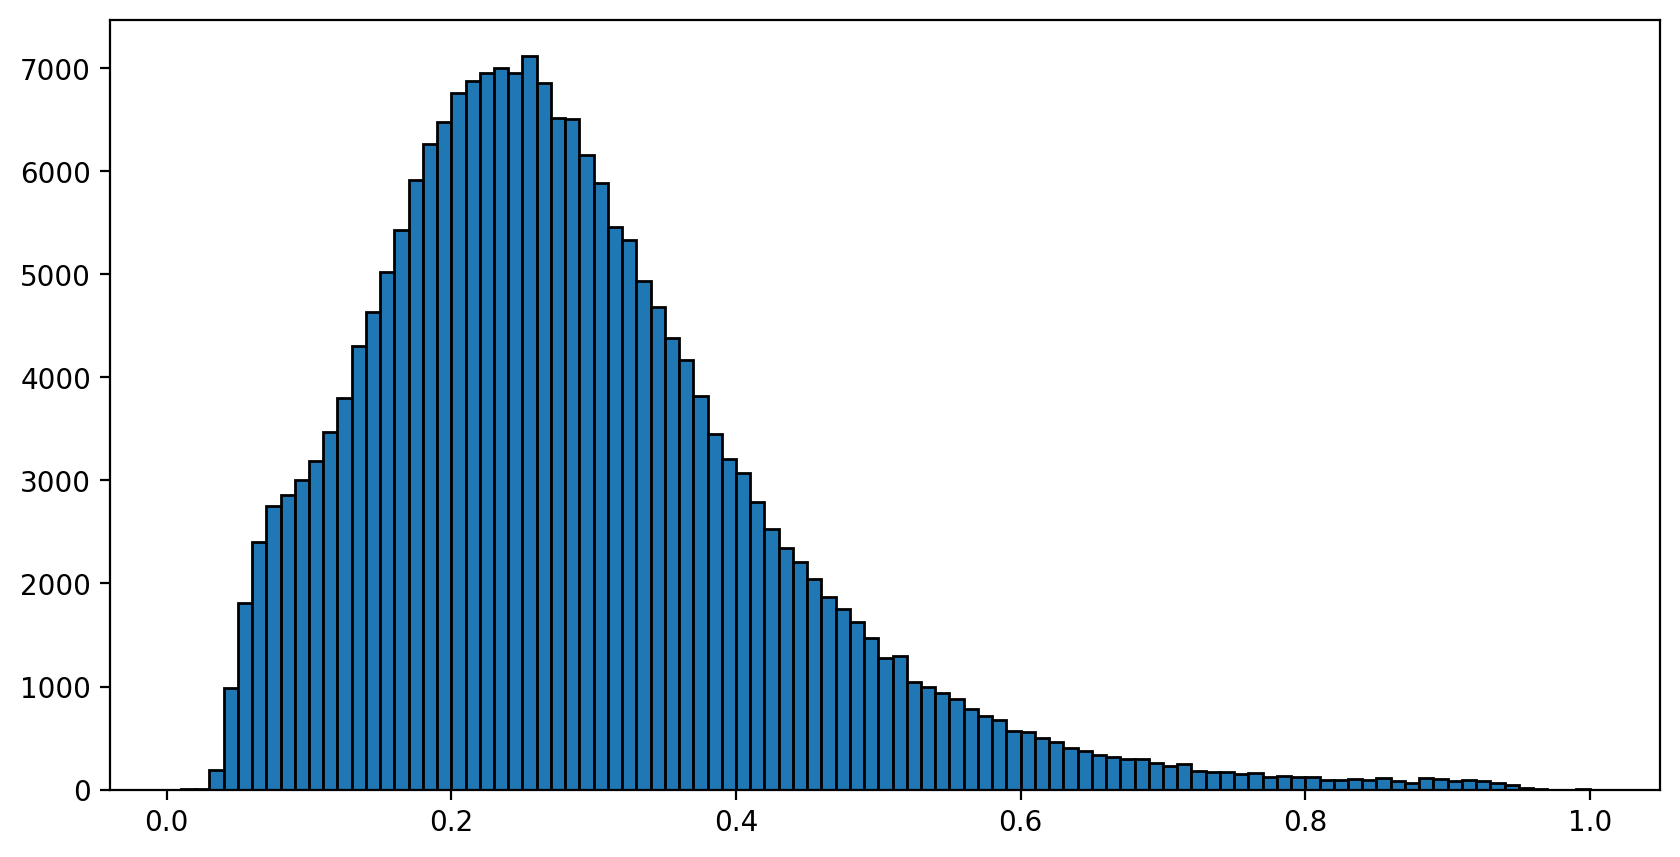

In [33]:
plt.figure(figsize=(10, 5))
plt.hist(tfi_nonzeros_scores, bins = np.arange(0.01,1.01, 0.01), edgecolor = "black");

In [34]:
tfi_nonzeros_scores.min()

np.float64(0.0185961526376087)

In [35]:
happiness_indices = hs_df[(hs_df['emotion'] == 'happiness')].index
sadness_indices = hs_df[(hs_df['emotion'] == 'sadness')].index
happiness_indices, sadness_indices

(Index([     6,     31,    117,    133,    276,    315,    327,    458,    465,
           638,
        ...
        393124, 393152, 393273, 393459, 393518, 393698, 393748, 393782, 393796,
        393817],
       dtype='int64', length=13038),
 Index([    83,    121,    144,    148,    176,    283,    292,    322,    383,
           385,
        ...
        393369, 393416, 393418, 393433, 393560, 393670, 393693, 393742, 393809,
        393812],
       dtype='int64', length=8485))

In [36]:
happiness_scores_df = tfi_df.loc[happiness_indices] 
happiness_nonzero_scores = happiness_scores_df.to_numpy().flatten()
happiness_nonzero_scores = happiness_nonzero_scores [happiness_nonzero_scores > 0]
happiness_nonzero_scores

array([0.17823756, 0.15860718, 0.10665379, ..., 0.35613054, 0.62360519,
       0.27589503], shape=(131518,))

In [37]:
sadness_scores_df = tfi_df.loc[sadness_indices] 
sadness_nonzero_scores = sadness_scores_df.to_numpy().flatten()
sadness_nonzero_scores = sadness_nonzero_scores [sadness_nonzero_scores > 0]
sadness_nonzero_scores

array([0.30690796, 0.31985013, 0.3334495 , ..., 0.10134642, 0.13128047,
       0.34356056], shape=(81768,))

Text(0.5, 1.0, 'tf-idf scores of happiness vs. sadness labels')

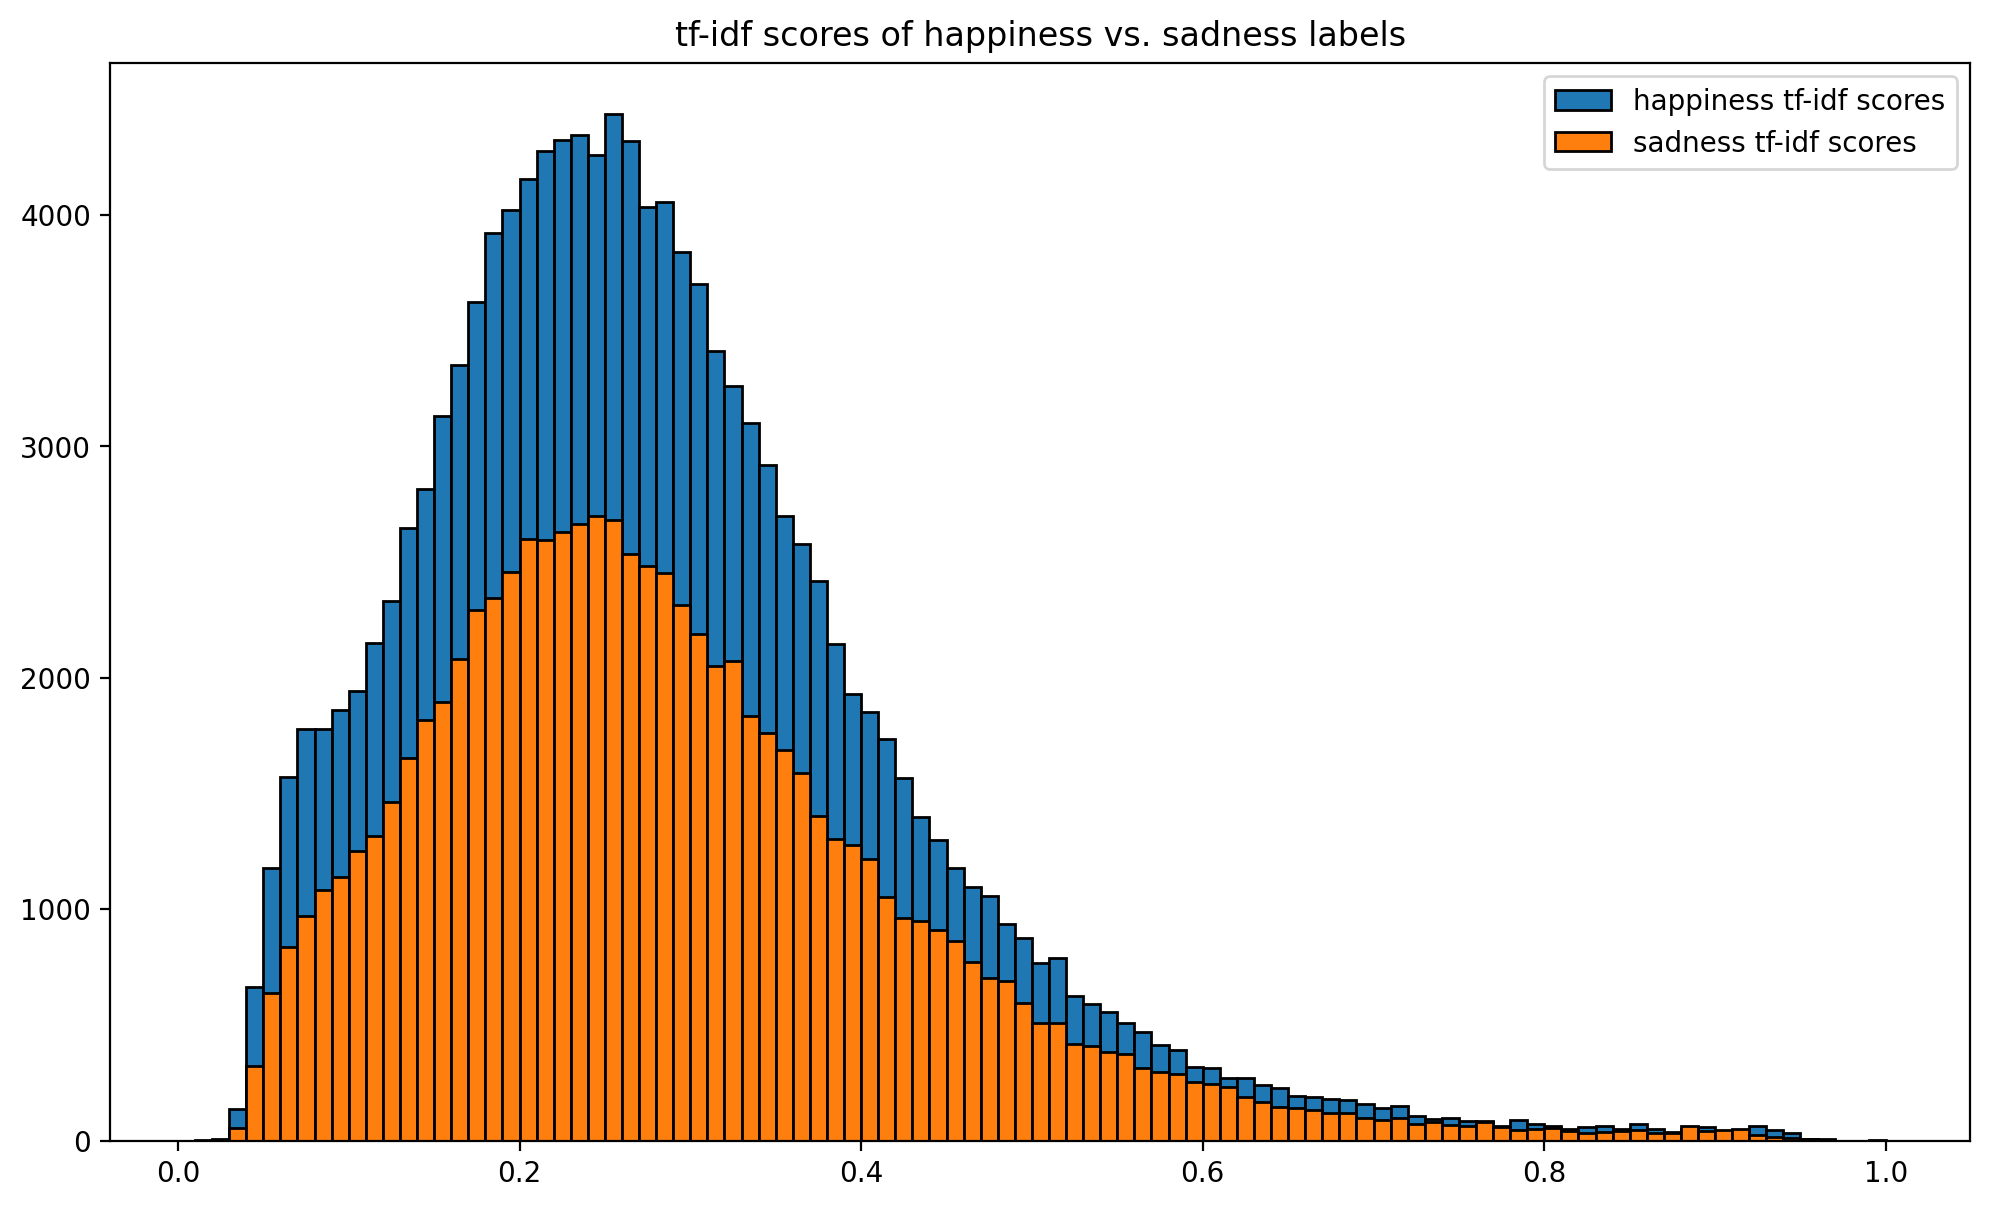

In [38]:
plt.hist(happiness_nonzero_scores, bins = np.arange(0.01,1.01, 0.01), edgecolor = "black", label='happiness tf-idf scores');
plt.hist(sadness_nonzero_scores, bins = np.arange(0.01,1.01, 0.01), edgecolor = "black", label='sadness tf-idf scores');
plt.legend();
plt.title("tf-idf scores of happiness vs. sadness labels")

In [39]:
#how to get words with tfi above .8
#tfi_df.T[(tfi_df.T > 0.8).any(axis=1)].index.to_numpy()

<span style='font-size:xx-large'>Word Cloud</span>


Based off of the visualization, we can see that the words "feel", "happy", and "feeling" are the words that appear most frequently in the happy emotion and the words "feel", "sad", and "feeling" are the word that appaear the most frequently in the happy emotion.



In [40]:
happiness_df = em_df[em_df["emotion"] == "happiness"].copy()
sadness_df = em_df[em_df["emotion"] == "sadness"].copy()

happiness_text = " ".join(happiness_df["text"])
sadness_text = " ".join(sadness_df["text"])

(np.float64(-0.5), np.float64(799.5), np.float64(399.5), np.float64(-0.5))

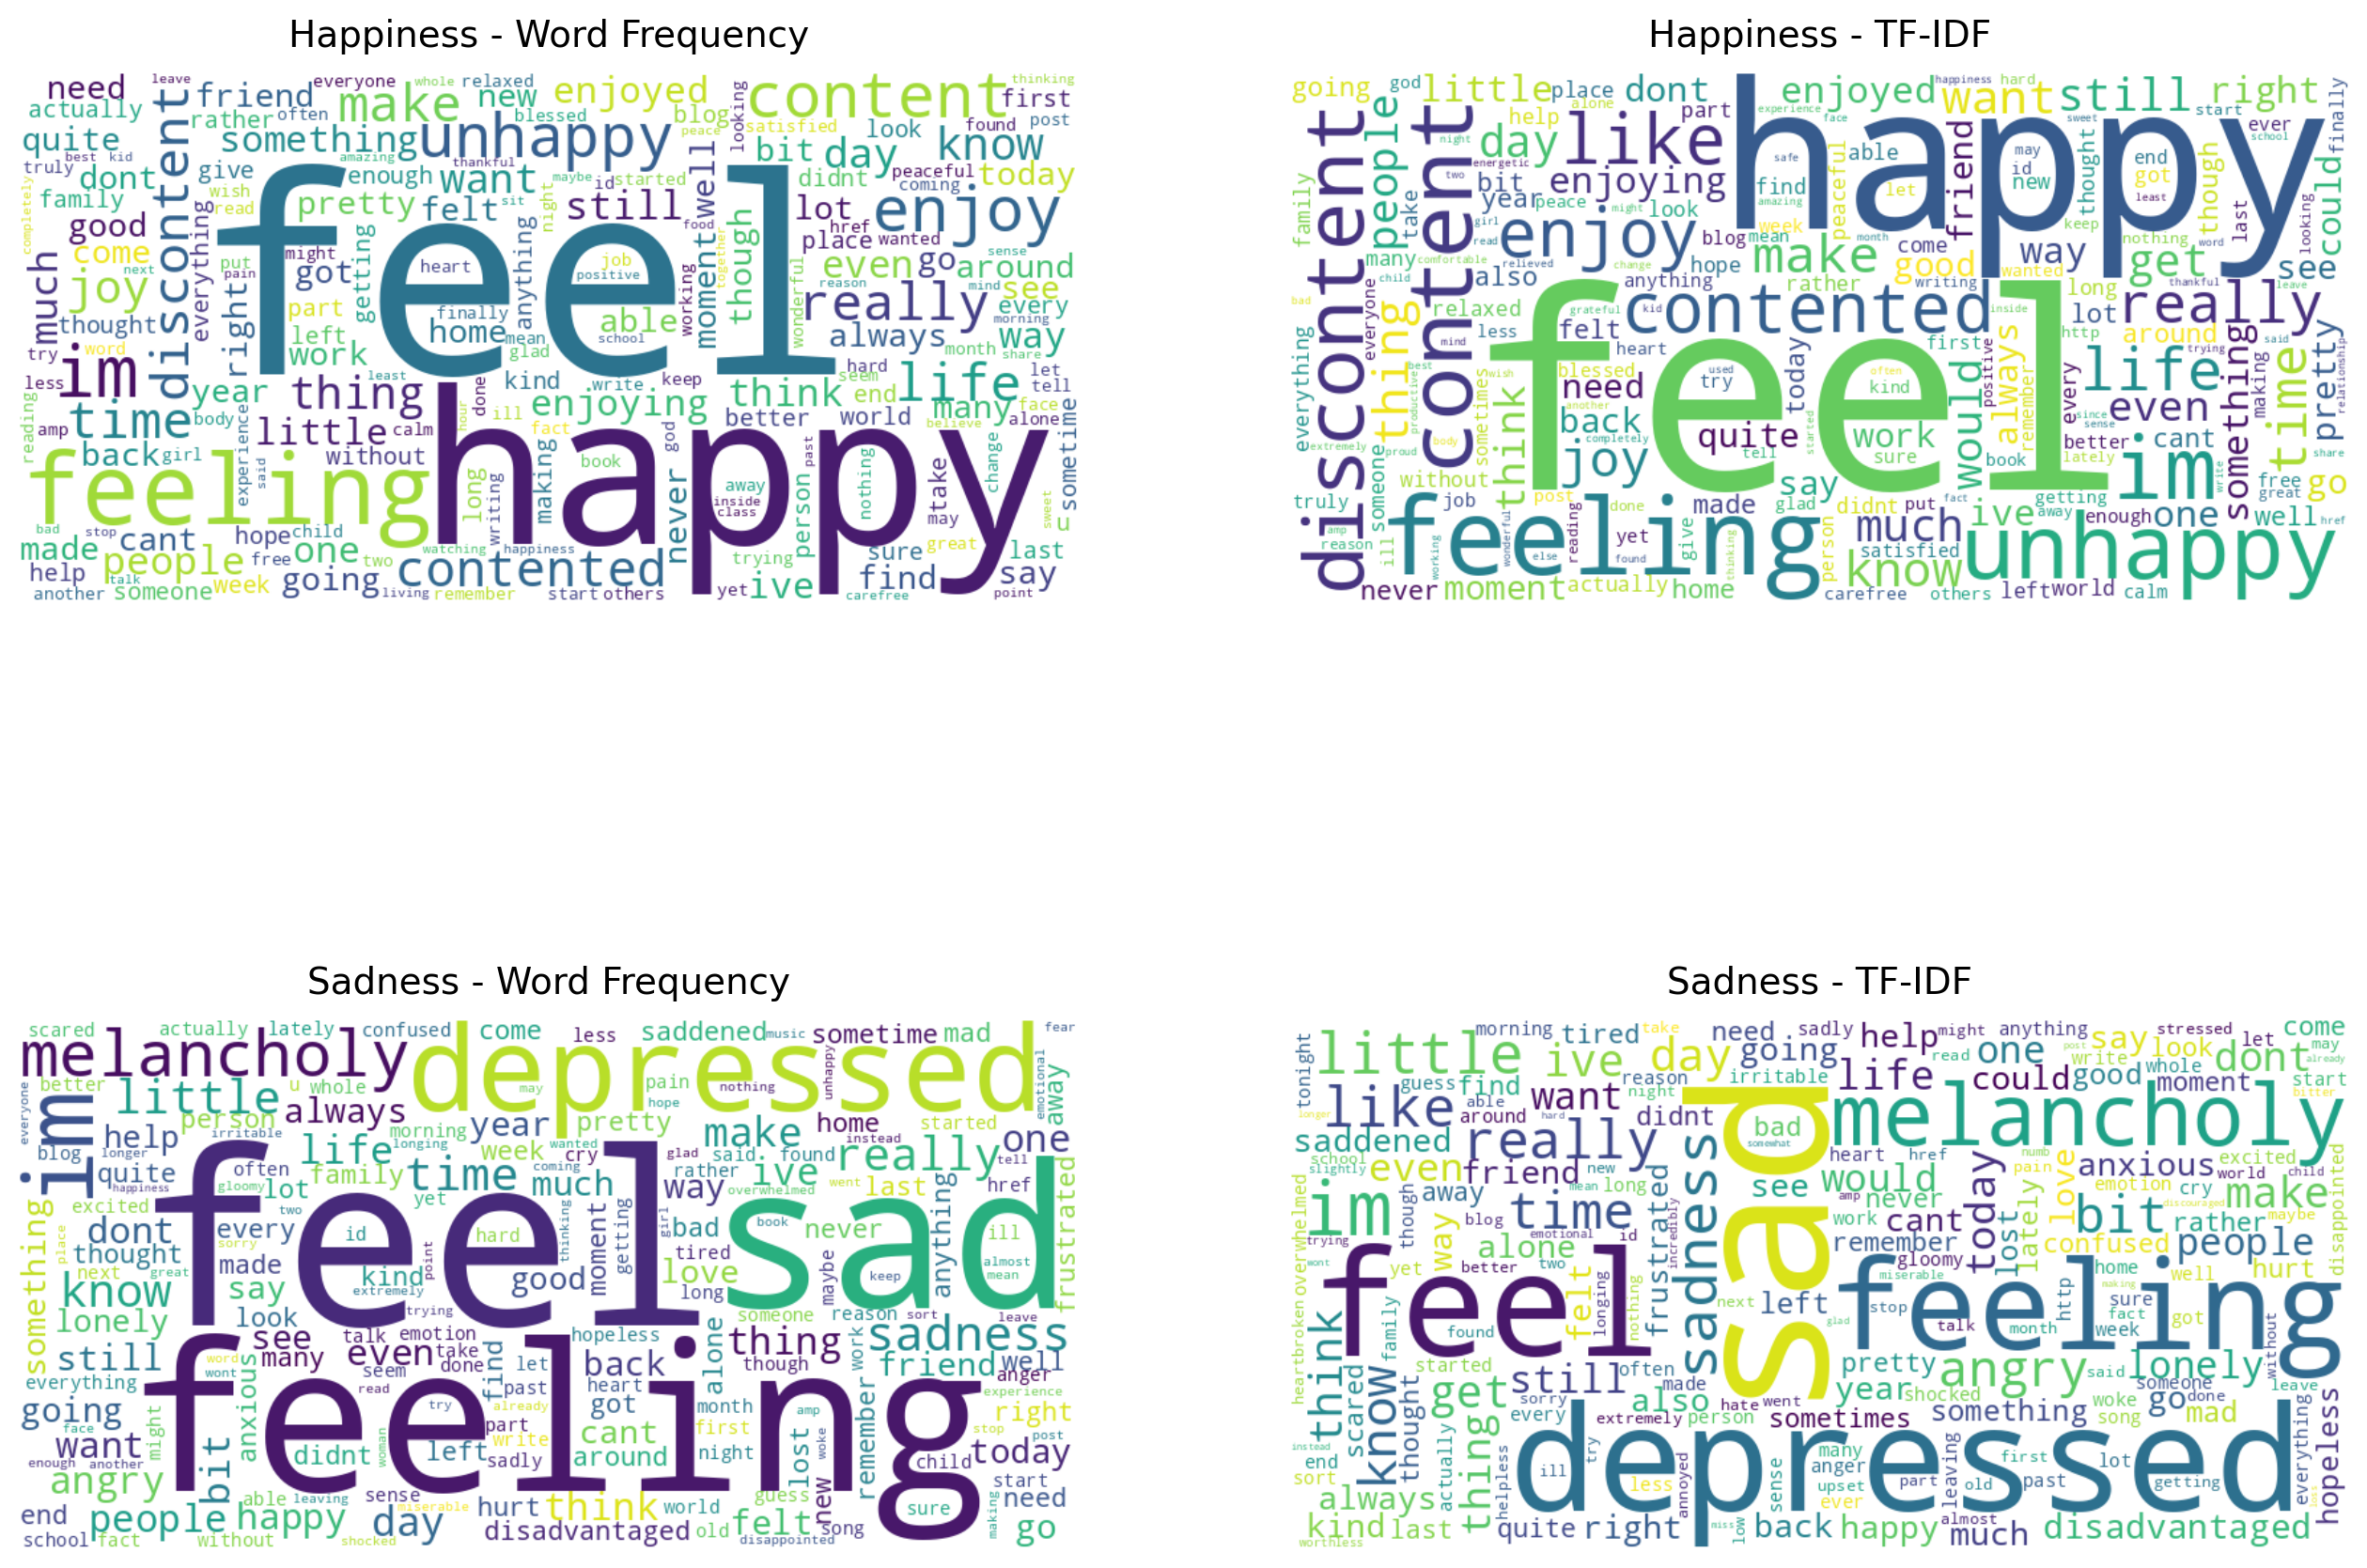

In [41]:
#Happiness Frequency
wc_happiness_freq = WordCloud(
    width=800,
    height=400,
    background_color="white",
    collocations=False
).generate(happiness_text)


#Sadness Frequency
wc_sadness_freq = WordCloud(
    width=800,
    height=400,
    background_color="white",
    collocations=False
).generate(sadness_text)


#Happiness TF-ID
word_importance = happiness_scores_df.sum(axis=0).to_dict()
happiness_tf_wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_importance)

#Sadness TF-IDF
word_importance = sadness_scores_df.sum(axis=0).to_dict()
sadness_tf_wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_importance)


fig, axs = plt.subplots(2, 2, figsize=(16, 12))


axs[0, 0].imshow(wc_happiness_freq, interpolation='bilinear')
axs[0, 0].set_title("Happiness - Word Frequency", fontsize=14, pad=10)
axs[0, 0].axis('off')

axs[0, 1].imshow(happiness_tf_wordcloud, interpolation='bilinear')
axs[0, 1].set_title("Happiness - TF-IDF", fontsize=14, pad=10)
axs[0, 1].axis('off')

axs[1, 0].imshow(wc_sadness_freq, interpolation='bilinear')
axs[1, 0].set_title("Sadness - Word Frequency", fontsize=14, pad=10)
axs[1, 0].axis('off')

axs[1, 1].imshow(sadness_tf_wordcloud, interpolation='bilinear')
axs[1, 1].set_title("Sadness - TF-IDF", fontsize=14, pad=10)
axs[1, 1].axis('off')

# Test / Train Data



In [153]:
SEED = 3

In [154]:
#Here we split the data into a test and training set
X = tfi_df
y = hs_df['emotion']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state = SEED
)

In [155]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((17218, 14847), (4305, 14847), (17218,), (4305,))

In [156]:
X_train.head(5)

,aa,aaaand,aallll,aaron,aate,ab,aback,abandon,abandoned,abandoning,...,zimbabwe,zine,zines,zipper,zoloft,zombie,zone,zoo,zoom,zoomed
298812,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
43446,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
351524,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
378327,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1857,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [157]:
X_test.head(5)

,aa,aaaand,aallll,aaron,aate,ab,aback,abandon,abandoned,abandoning,...,zimbabwe,zine,zines,zipper,zoloft,zombie,zone,zoo,zoom,zoomed
202213,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
257492,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
79941,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
291016,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
302781,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [158]:
y_train.head(5)

298812    happiness
43446     happiness
351524    happiness
378327    happiness
1857      happiness
Name: emotion, dtype: object

In [159]:
y_test.head(5)

202213    happiness
257492      sadness
79941       sadness
291016    happiness
302781      sadness
Name: emotion, dtype: object

# Logistic Regression

[https://www.kaggle.com/code/mwaseem75/scikit\-logistic\-regression\-with\-confusion\-matrix](https://www.kaggle.com/code/mwaseem75/scikit-logistic-regression-with-confusion-matrix) 


In [160]:
lr_model = LogisticRegression()

lr_model.fit(X_train,y_train)
lr_model

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [161]:
lr_model.classes_
(lr_model.coef_ > 0).sum()
lr_model.intercept_
lr_model.n_features_in_
lr_model.feature_names_in_
lr_model.n_iter_

array([12], dtype=int32)

# Assessing The LR Model on Training Data

In [162]:
lr_preds_train = lr_model.predict(X_train)
lr_preds_acc_train = (lr_preds_train == y_train).sum() / len(lr_preds_train)
lr_preds_acc_train

np.float64(0.9939017307468928)

In [163]:
lr_probabilities_train = lr_model.predict_proba(X_train)
lr_probabilities_train

array([[0.9397455 , 0.0602545 ],
       [0.95737722, 0.04262278],
       [0.92248119, 0.07751881],
       ...,
       [0.93768223, 0.06231777],
       [0.23124456, 0.76875544],
       [0.0416414 , 0.9583586 ]], shape=(17218, 2))

In [164]:
cnf_matrix = confusion_matrix(y_train, lr_preds_train,labels = lr_model.classes_)
cnf_matrix

array([[10404,     0],
       [  105,  6709]])

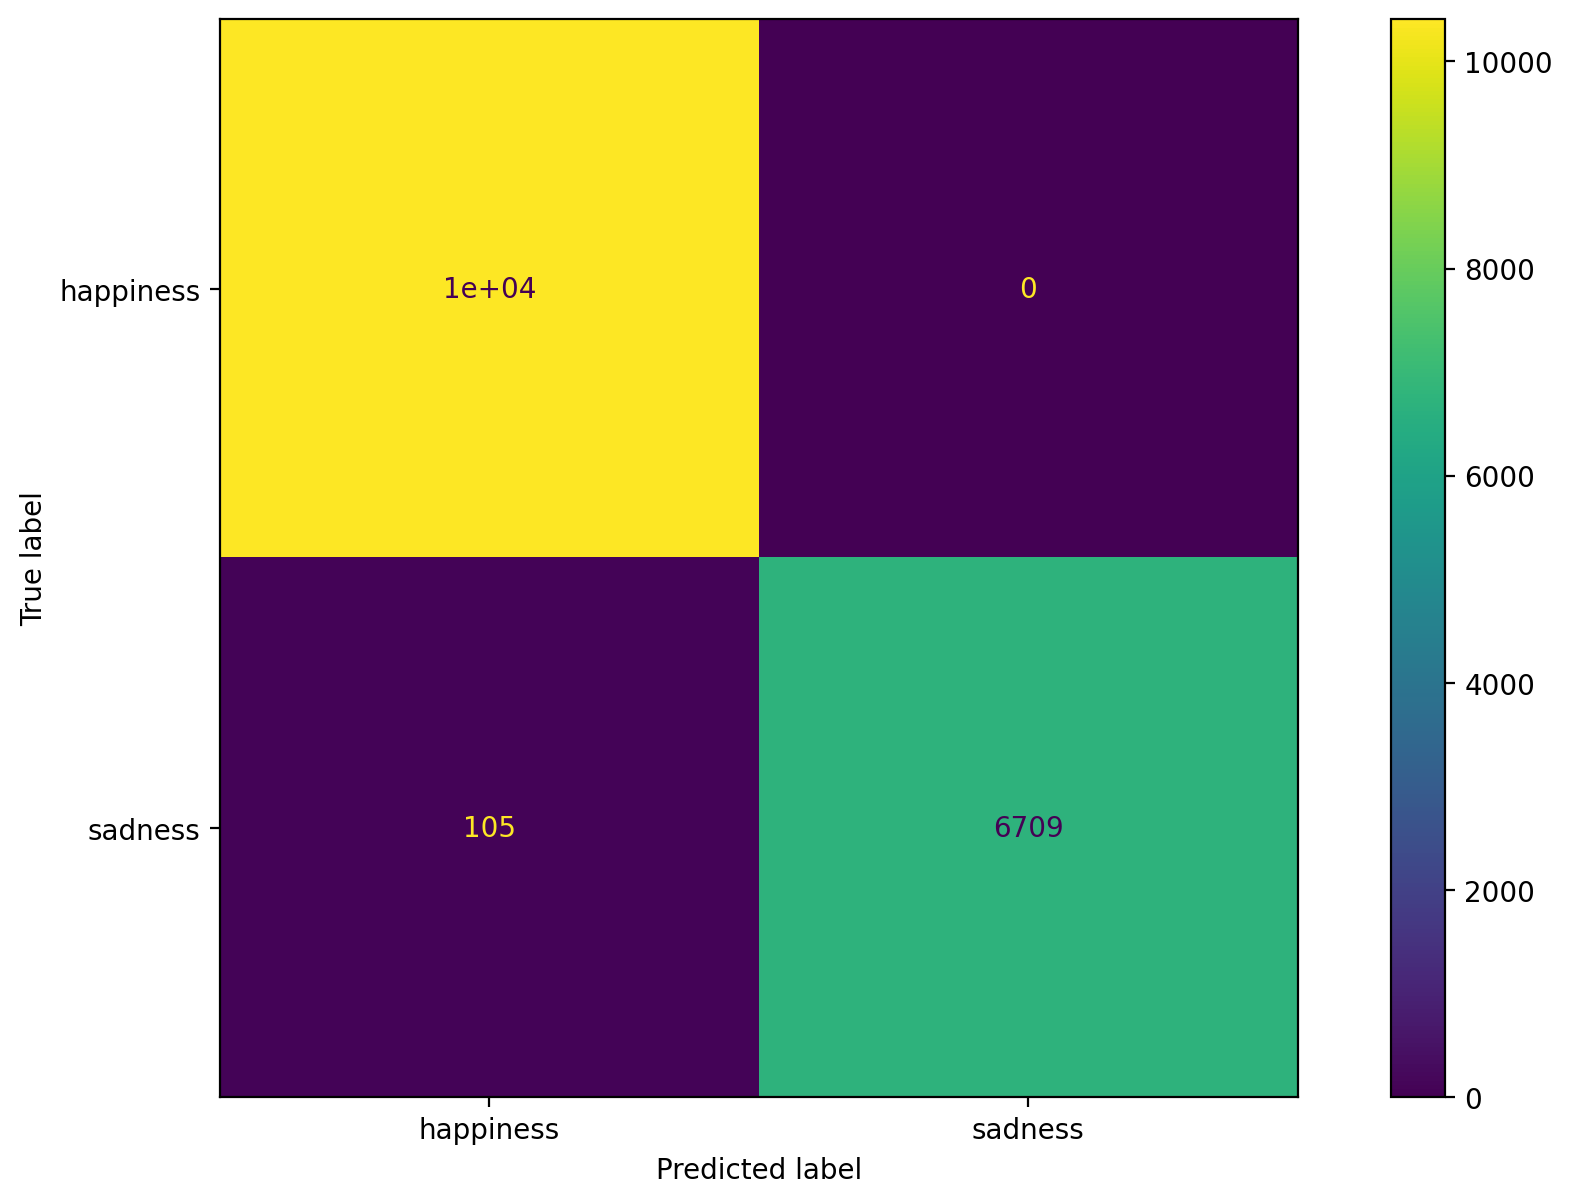

In [165]:
disp = ConfusionMatrixDisplay(confusion_matrix=cnf_matrix,
                              display_labels=lr_model.classes_)
disp.plot();

In [166]:
recall = (10433)/(10433 + 0)
print(recall)

precision = (10433)/(10433 + 100)
print(precision)

f_one = 2 * ((precision * recall)/(precision + recall))
print(f_one)


1.0
0.9905060286717934
0.9952303729848326


In [167]:
lr_probabilities_train[:,0] > 0.8

array([ True,  True,  True, ...,  True, False, False], shape=(17218,))

In [168]:
fpr, tpr, thresholds = roc_curve(y_train == "happiness", lr_probabilities_train[:,0])
fpr, tpr, thresholds

(array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.000000

In [169]:
j_scores = tpr - fpr


best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]
best_threshold

np.float64(0.7124368613131076)

In [170]:
auc_score = auc(fpr, tpr)
print(f"Calculated AUC: {auc_score}")

Calculated AUC: 0.9999269460945401


Text(0.5, 1.0, 'Receiver Operating Characteristic')

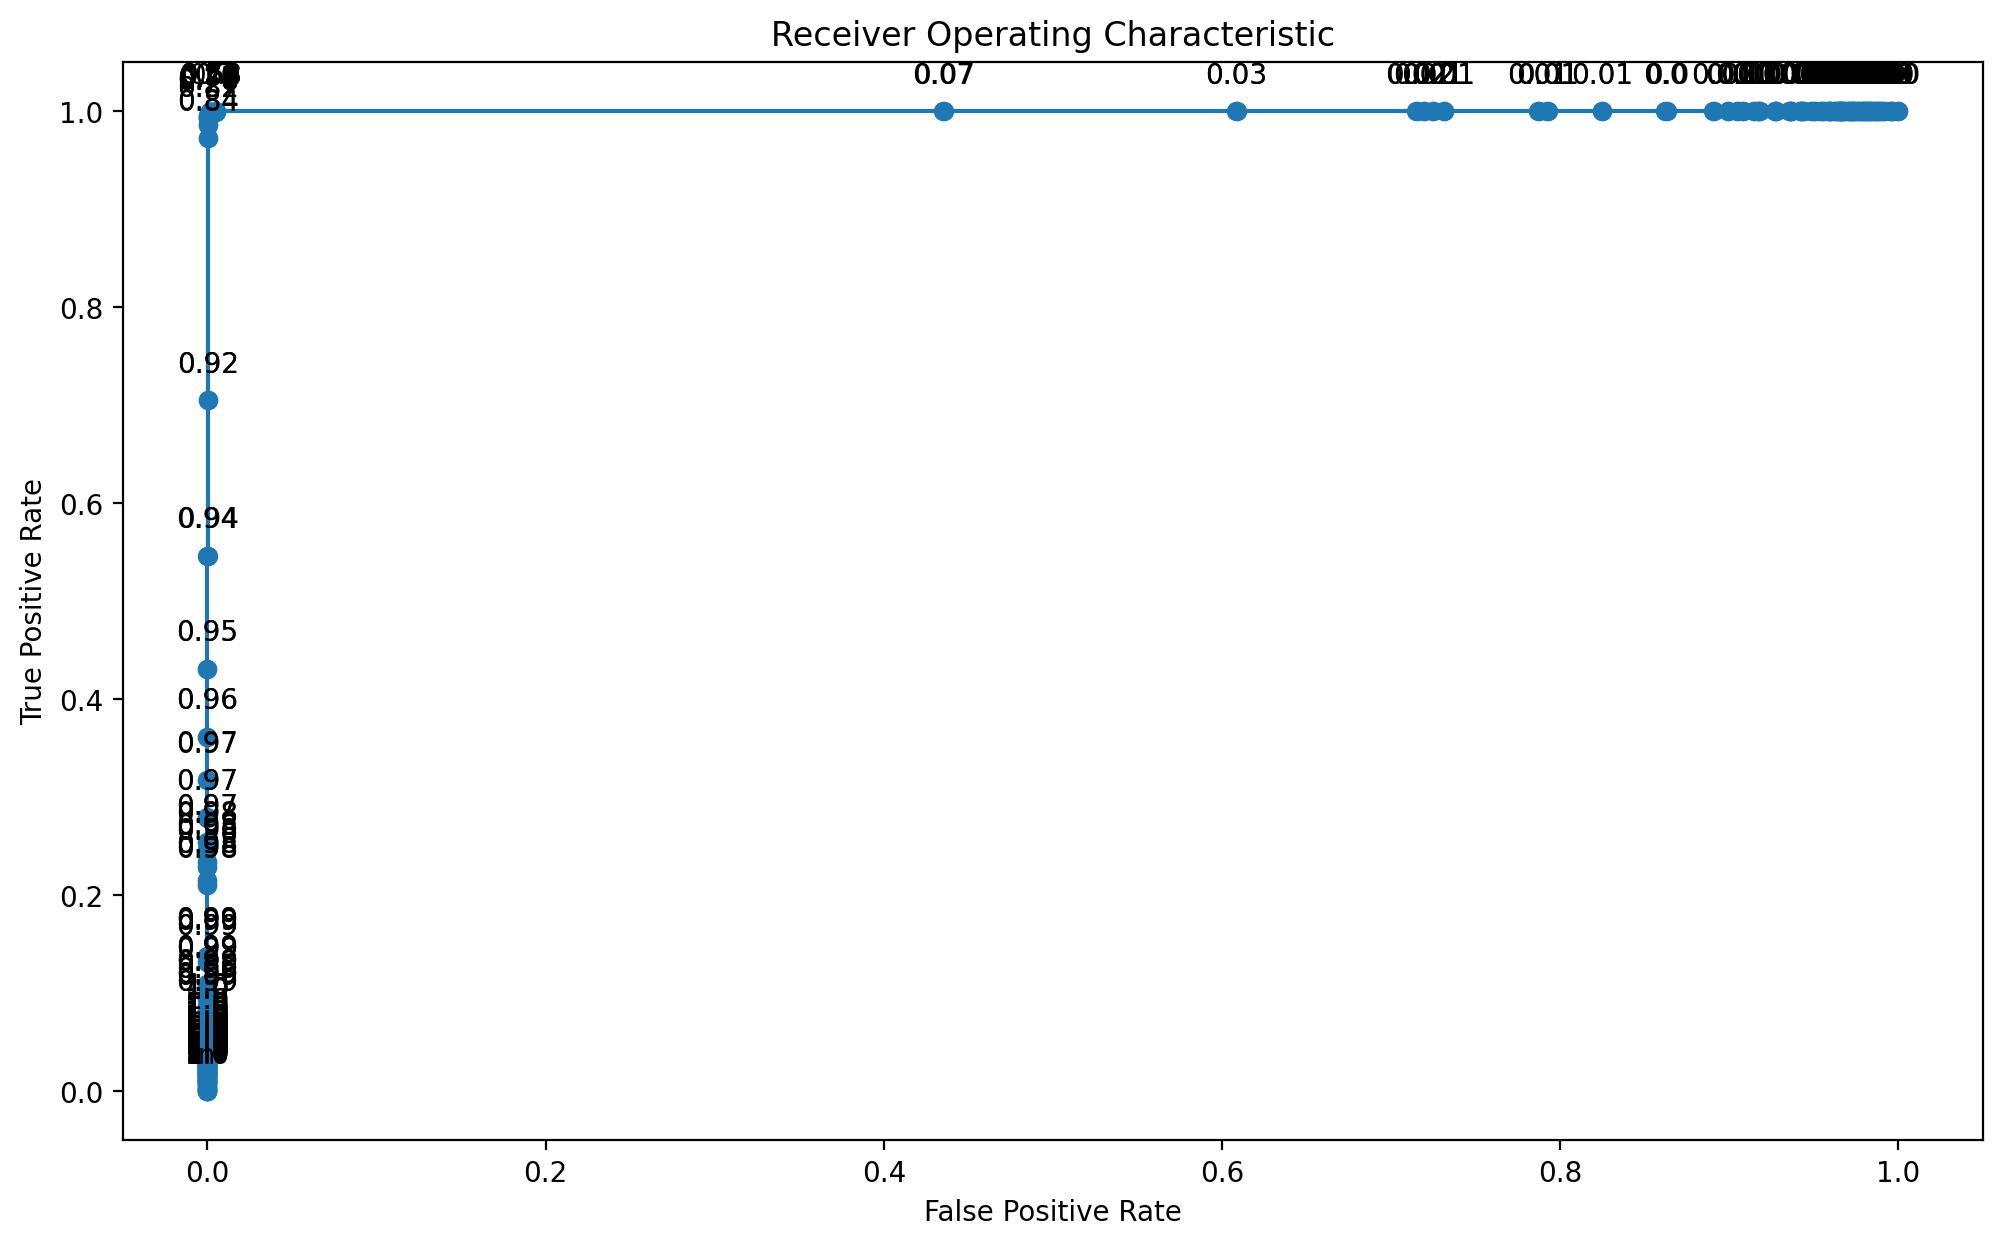

In [171]:
plt.plot(fpr, tpr, marker = "o")

for i, txt in enumerate(thresholds):
    plt.annotate(
        text=str(round(txt, 2)),               # Text to display
        xy=(fpr[i], tpr[i]),             # Point (x, y) to label
        xytext=(0, 10),              # Pixel offset from the point (dx, dy)
        textcoords="offset points",  # Tells matplotlib to interpret xytext as pixels
        ha='center'                  # Horizontally center the text
    )
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')

# Assessing The LR Model on Testing


In [172]:
lr_preds_test = lr_model.predict(X_test)
lr_preds_acc_test = (lr_preds_test == y_test).sum() / len(lr_preds_test)
lr_preds_acc_test

np.float64(0.989082462253194)

In [173]:
lr_probabilities_test = lr_model.predict_proba(X_test)
lr_probabilities_test

array([[0.90925267, 0.09074733],
       [0.26755944, 0.73244056],
       [0.00236003, 0.99763997],
       ...,
       [0.03417194, 0.96582806],
       [0.93978281, 0.06021719],
       [0.91406051, 0.08593949]], shape=(4305, 2))

In [174]:
cnf_matrix_test = confusion_matrix(y_test, lr_preds_test,labels = lr_model.classes_)
cnf_matrix_test

array([[2634,    0],
       [  47, 1624]])

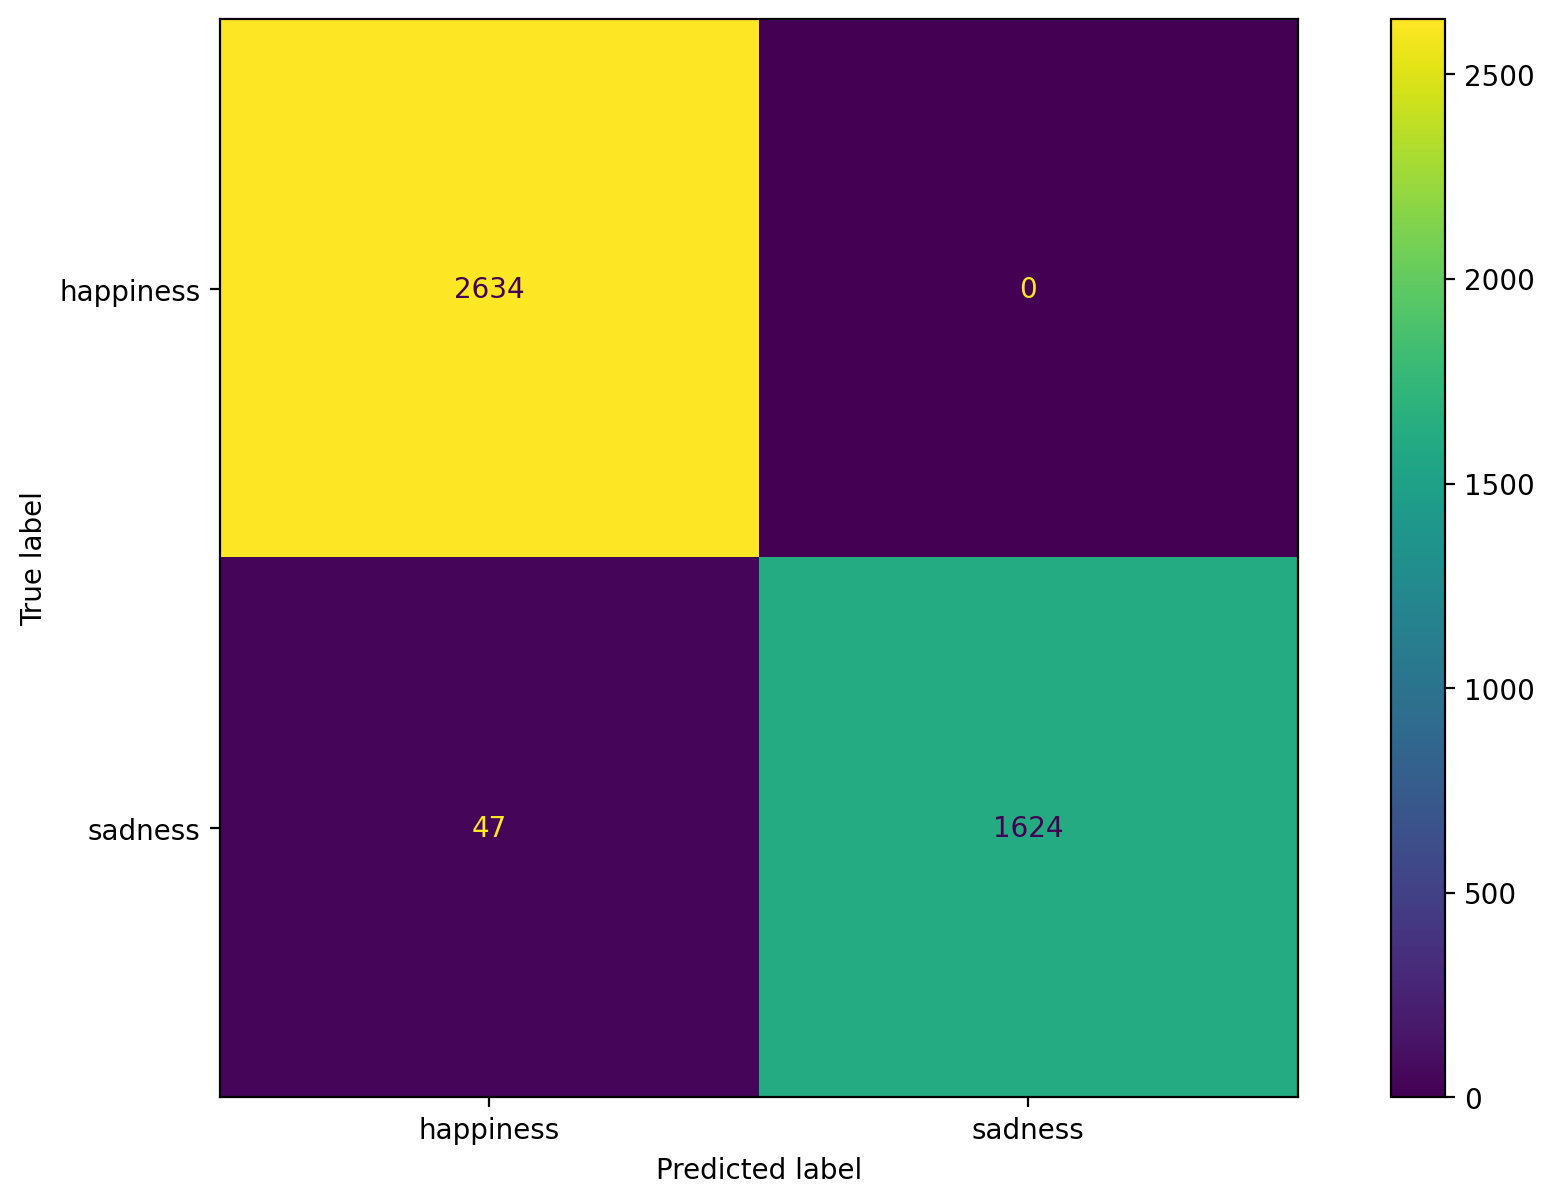

In [175]:
disp = ConfusionMatrixDisplay(confusion_matrix=cnf_matrix_test,
                              display_labels=lr_model.classes_)
disp.plot();

In [176]:
recall = (2605)/(2605 + 0)
print(recall)

precision = (2605)/(2605 + 41)
print(precision)

f_one = 2 * ((precision * recall)/(precision + recall))
print(f_one)


1.0
0.9845049130763417
0.9921919634355361


In [177]:
lr_probabilities_test[:,0] > 0.8

array([ True, False, False, ..., False,  True,  True], shape=(4305,))

In [178]:
fpr_test, tpr_test, thresholds_test = roc_curve(y_test == "happiness", lr_probabilities_test[:,0])
fpr_test, tpr_test, thresholds_test

(array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 5.98444045e-04,
        5.98444045e-04, 5.98444045e-04, 5.98444045e-04, 1.19688809e-03,
        1.19688809e-03, 1.79533214e-03, 1.79533214e-03, 2.39377618e-03,
        2.39377618e-03, 2.99222023e-03, 2.99222023e-03, 3.59066427e-03,
        3.59066427e-03, 4.18910832e-03, 4.18910832e-03, 4.78755236e-03,
        4.78755236e-03, 7.18132855e-03, 7.18132855e-03, 8.378216

In [179]:
j_scores = tpr_test - fpr_test


best_idx = np.argmax(j_scores)
best_threshold = thresholds_test[best_idx]
best_threshold

np.float64(0.7048662210117093)

In [180]:
auc_score_test = auc(fpr_test, tpr_test)
print(f"Calculated AUC: {auc_score_test}")

Calculated AUC: 0.9988937645947416


Text(0.5, 1.0, 'ROC Curve (Calculated AUC: 0.9988937645947416)')

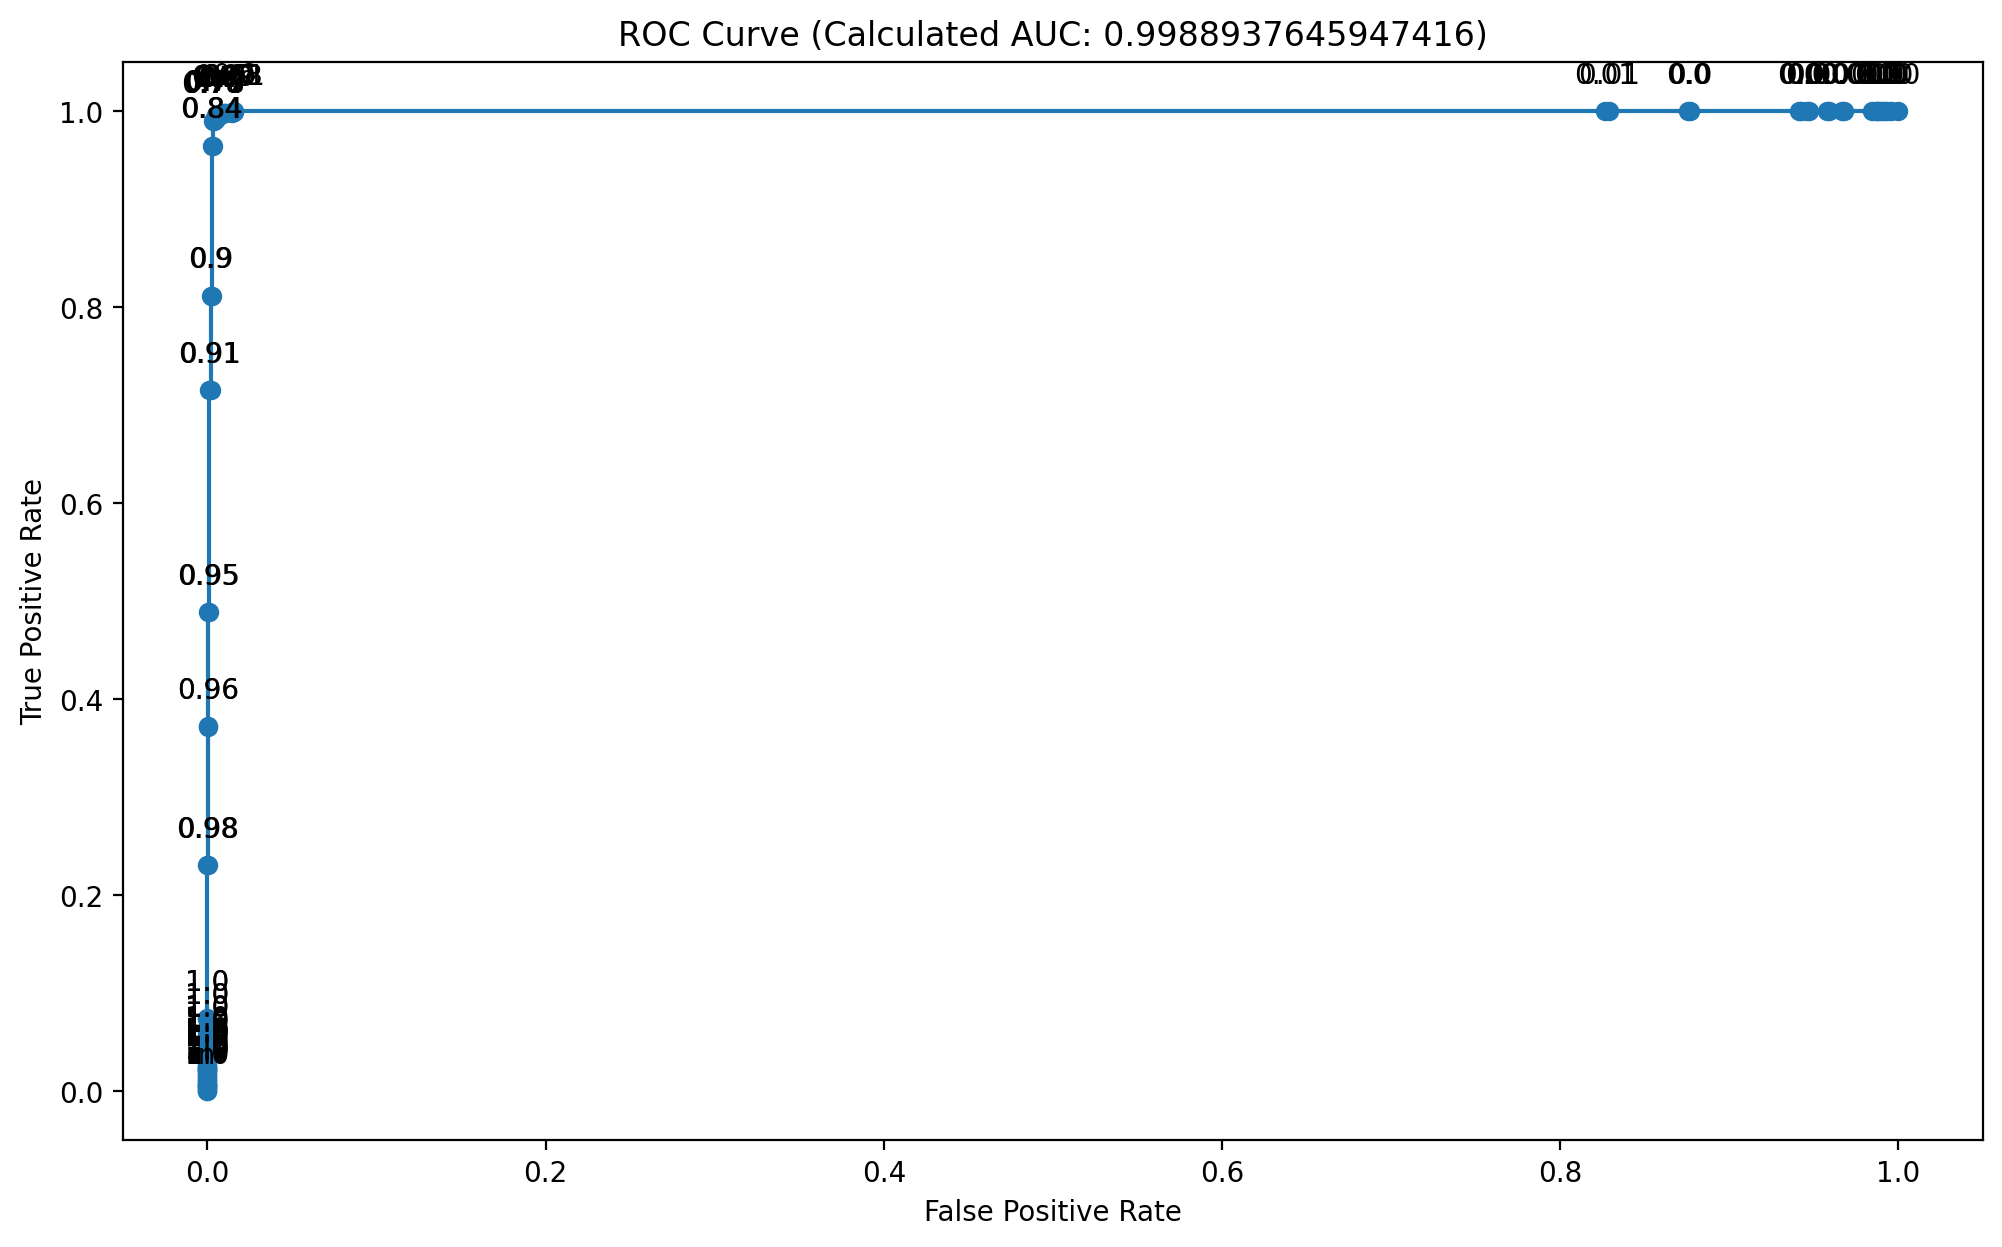

In [181]:
plt.plot(fpr_test, tpr_test, marker = "o")
for i, txt in enumerate(thresholds_test):
    plt.annotate(
        text=str(round(txt, 2)),               # Text to display
        xy=(fpr_test[i], tpr_test[i]),             # Point (x, y) to label
        xytext=(0, 10),              # Pixel offset from the point (dx, dy)
        textcoords="offset points",  # Tells matplotlib to interpret xytext as pixels
        ha='center'                  # Horizontally center the text
    )
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve (Calculated AUC: {auc_score_test})')

# Exploratory Analysis

How many contain happy or sad?

Most frequently occurring words of length 4 or more for each category?

Word after a phrase like "I feel"

